Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split



Loading Dataset

In [ ]:
df=pd.read_csv("/content/archive (2).zip")

Dataset Information

In [ ]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


EDA (Exploratory Data Analysis)

In [ ]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [ ]:
df.shape

(2000, 10)

In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


Data Cleaning

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)


Data Visualization

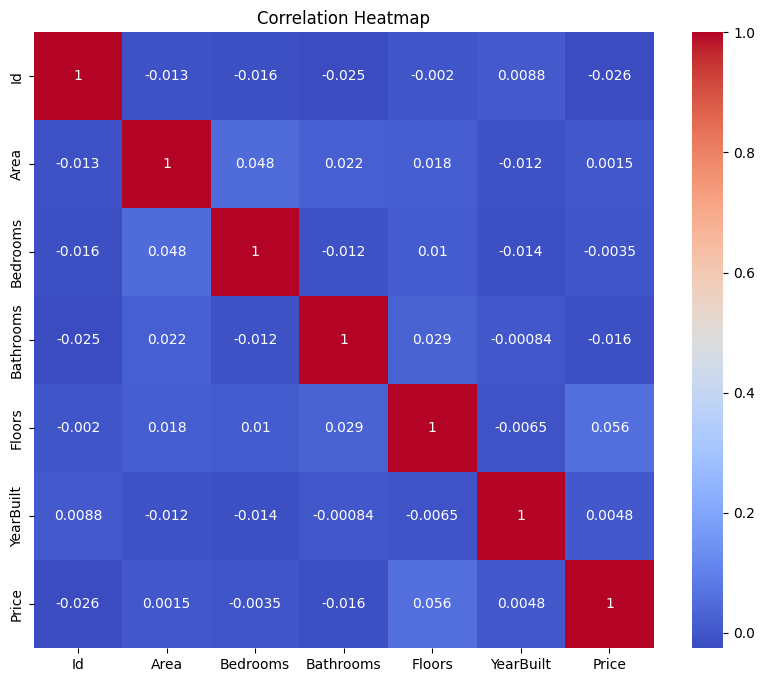

In [38]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

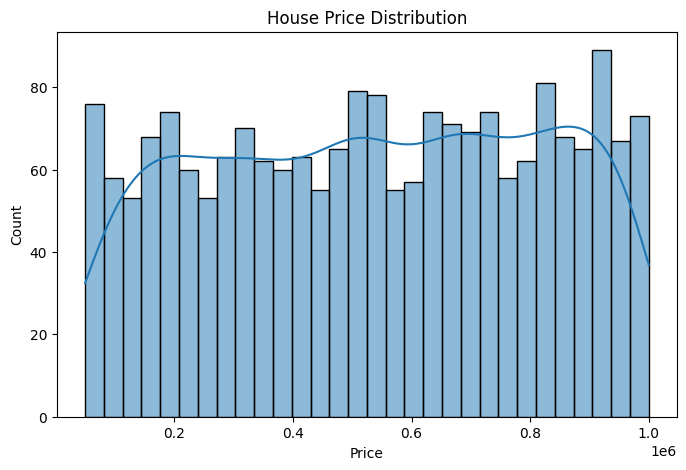

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("House Price Distribution")
plt.show()

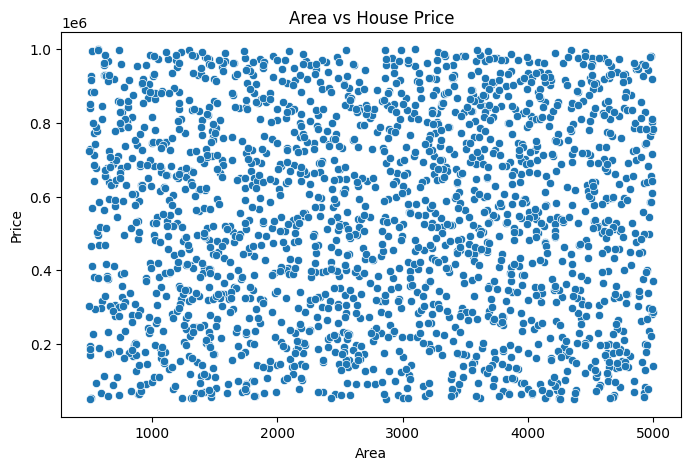

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Area'], y=df['Price'])
plt.title("Area vs House Price")
plt.show()

Feature Selection

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

Converting Categorical Data

In [43]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

df_numeric.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
0,1,1360,5,4,3,1970,149919
1,2,4272,5,4,3,1958,424998
2,3,3592,2,2,3,1938,266746
3,4,966,4,2,2,1902,244020
4,5,4926,1,4,2,1975,636056


One Hot Encoding

In [40]:
X = pd.get_dummies(X, drop_first=True)

Spliting Dataset
TRAIN-TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Machine Learning Algorithms**

# LINEAR REGRESSION

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# DECISION TREE REGRESSOR

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# RANDOM FOREST REGRESSOR

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MODEL EVALUATION

In [30]:
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression
MAE: 242867.44926338628
MSE: 78279764120.86243
R2 Score: -0.006181784611834162


In [31]:
print("Decision Tree Regressor")
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("MSE:", mean_squared_error(y_test, dt_pred))
print("R2 Score:", r2_score(y_test, dt_pred))

Decision Tree Regressor
MAE: 321166.1675
MSE: 160628402306.5775
R2 Score: -1.0646635092389856


In [32]:
print("Random Forest Regressor")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Regressor
MAE: 249685.404225
MSE: 83274181705.09029
R2 Score: -0.07037835002606019


Accuracy Comparison Table

In [34]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})
print(results)

               Model  R2 Score
0  Linear Regression -0.006182
1      Decision Tree -1.064664
2      Random Forest -0.070378


Visualization of Model Comparison

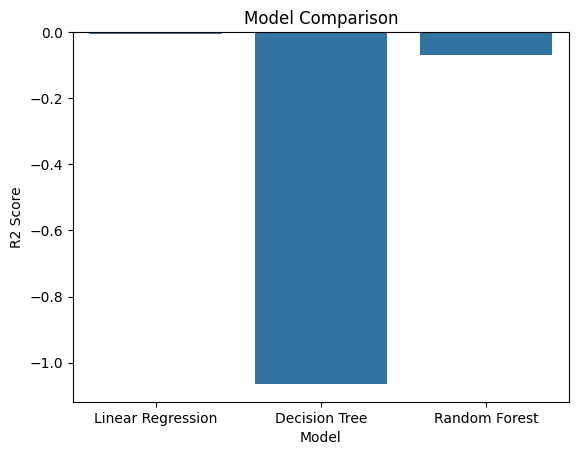

In [35]:
sns.barplot(x='Model', y='R2 Score', data=results)
plt.title("Model Comparison")
plt.show()

# CONCLUSION
In this project, a complete machine learning workflow was performed on the House Price Prediction Dataset to predict house prices based on different features such as area, bedrooms, bathrooms, location, and house condition. Data cleaning and preprocessing techniques were applied to handle categorical data and prepare the dataset for model training. Exploratory Data Analysis (EDA) and visualizations helped in understanding the relationships between features and house prices.
Three machine learning algorithms were implemented:
Linear Regression
Decision Tree Regressor
Random Forest Regressor
The results showed that all models produced negative R² scores, indicating that the dataset had weak relationships between features and target values. However, Linear Regression achieved the best performance with the highest R² score of -0.006182, which was closest to zero compared to the other models. Decision Tree Regressor performed the worst due to overfitting, while Random Forest Regressor showed moderate performance.
Overall, this project demonstrated the complete process of applying machine learning techniques for house price prediction and highlighted the importance of feature quality and preprocessing in improving model performance.